# **Focus Area 1 — Ground Observations Monitoring &amp; QC**
**Core Objective**: To equip NMHS participants with tools for quality-controlling ground station
data and validating it against satellite products, enabling identification of network issues and
building confidence in observational networks.

### **Overall notebook steps**
Set up
  - Step 1: Define variables to use in the analysis
  - Step 2: Setup – Install dependencies, authenticate Google Drive & Earth Engine

Data Extraction
  - Step 3: Visualise the area of interest
  - Step 4: Upload custom data or extract TAHMO data (Ground stations)
  - Step 5: Extract CHIRPS data

Data Processing
  - Step 6: Visualise data availability for ground stations and handle missing data

Data QC and comparison
  - Step 7: Aggregate the Ground data to Pentads
  - Step 8: Build CHIRPS Nearest data for the ground stations
  - Step 9: Visualise CHIRPS vs the Ground stations
  - Step 10: Compute station confidence scores

### **Station Scoring – Formula (0–100)**
We compute per-station metrics on **pentad totals** and convert them to a 0–100 score:

- **corr (r)** – higher is better
- **rmse** (mm/pentad) – lower is better
- **bias** (|gauge − CHIRPS|, mm/pentad) – lower is better
- **complete** – fraction of pentads that meet `MIN_PENTAD_DAYS` – higher is better
- **outlier** – fraction of pentads outside tolerance – lower is better

Weights are set in `SCORING_WEIGHTS` in the Config cell. The final score is:

```
score = 100 * [
  w_corr * norm_corr +
  w_rmse * (1 - norm_rmse) +
  w_bias * (1 - norm_bias) +
  w_complete * complete +
  w_outlier * (1 - outlier)
]
```
with simple min–max normalization of rmse/bias over stations.


### **Instructions to use custom data**

To use custom data you require 2 files
- The Metadata file: Ground_Metadata.csv
- The Ground_station data file: Ground_data.csv

**Recommended file format and structure (Columns)**:
<!DOCTYPE html>
<html>
<head>
    <title>Ground_Metadata.csv</title>
</head>
<body>
    <table border="1">
        <tr>
            <th>Code</th>
            <th>lat</th>
            <th>lon</th>
        </tr>
        <tr>
            <td>Station1</td>
            <td>1.2345</td>
            <td>36.7890</td>
        </tr>
        <!-- More rows as needed -->
    </table>
    <p><p>
</html>

Data file format (Columns): Precipitation data for multiple stations
<html>
<head>
    <title>Ground_data.csv</title>
</head>
<body>
    <table border="1">
        <tr>
            <th>Date</th>
            <th>Station1</th>
            <th>Station2</th>
            <th>Station3</th>
            <!-- More station codes as needed -->
        </tr>
        <tr>
            <td>2023-01-01</td>
            <td>25.3</td>
            <td>26.1</td>
            <td>24.8</td>
        </tr>
        <!-- More rows as needed -->
    </table>
</html>

# **Step 1: Define variables to use in the analysis**

In [12]:
## === CONFIG (edit here) ======================================================

import os
import numpy as np
from datetime import date

# Define data source to be used for ground stations data
Ground_data_source = "TAHMO"  # use 'custom' or 'TAHMO'

# Country / ROI
COUNTRY = 'Ethiopia'          # 'Ethiopia' | 'Djibouti' | 'Tanzania' | 'Eritrea'
ROI_METHOD = 'OSM'            # 'OSM' (default) or 'GMAPS' if API key available

# Dates
start_date = '2025-02-01'     # ISO format
end_date   = '2025-07-31'

# Output directory (created locally in the current working directory)
RUN_STAMP = date.today().isoformat()
BASE_OUT = os.path.join('./outputs', f'NOAA_QC_RUN_{COUNTRY}_{RUN_STAMP}')
os.makedirs(BASE_OUT, exist_ok=True)

# QC thresholds
QC_LIMITS = {
    'rain_min': 0.0,
    'rain_spike_mm': 300.0,    # flag if a single day exceeds this
    'flatline_days': 7,        # flag if >=N days unchanged
}

# Aggregation & matching
CHIRPS_AGG = 'pentad'          # currently pentad-based comparison
MIN_PENTAD_DAYS = 3            # minimum valid daily values to accept a pentad
NEIGHBORHOOD = 3               # 1 (nearest pixel), 3 or 5 for mean of NxN neighborhood

# Scoring weights (must sum to 1.0)
w_corr = 0.5     # Pearson/Spearman r (higher is better)
w_bias = 0.3     # absolute bias (lower is better)
w_complete = 0.1 # pentad completeness (higher is better)
w_outlier = 0.1  # outlier rate (lower is better)

# Correlation method
CORR_METHOD = 'spearman'       # Use 'pearson' or 'spearman'

# Confidence definition (Changed to integers to prevent TypeErrors in later steps)
High_confidence_threshold = 70
Low_confidence_threshold = 30

# Reproducibility
np.random.seed(42)
print('✅ CONFIG set. Outputs will be written to:', BASE_OUT)

# Alias for backward compatibility with later steps
RESULTS_DIR = BASE_OUT
# ── LOCAL DIRS (Colab temp storage per country) ───────────────────────────────
COUNTRY_LOCAL_DIR = os.path.join('./Datasets', COUNTRY)
os.makedirs(COUNTRY_LOCAL_DIR, exist_ok=True)

# Global directory path for ground data (used in Steps 4 and 6)
dir_path = COUNTRY_LOCAL_DIR


✅ CONFIG set. Outputs will be written to: ./outputs/NOAA_QC_RUN_Ethiopia_2026-07-01


# **Step 2: Setup – Install dependencies, authenticate Google Drive & Earth Engine**

In [13]:
# @title ### 2a) Install dependencies & Smart Caching via Shared Drive {"display-mode":"form"}
# @markdown This cell installs the required dependencies, imports libraries, and mounts the Shared Drive for smart caching.

# ── 1. INSTALL DEPENDENCIES ───────────────────────────────────────────────────
print("Installing required dependencies...")
!pip install git+https://github.com/TAHMO/NOAA.git > /dev/null 2>&1
!pip install scipy --upgrade > /dev/null 2>&1
!pip install gdown -q > /dev/null 2>&1

!jupyter nbextension enable --py widgetsnbextension > /dev/null 2>&1
print("✅ Dependencies installed successfully.")

# ── 2. IMPORT LIBRARIES ───────────────────────────────────────────────────────
print("Importing required libraries...")
import pandas as pd
import matplotlib.pyplot as plt
import os, json, shutil
import ee
import xarray as xr
import numpy as np
from scipy.stats import pearsonr, ttest_rel

from utils.ground_stations import plot_stations_folium
from utils.helpers import get_region_geojson
from utils.CHIRPS_helpers import get_chirps_pentad_gee
from utils.plotting import plot_xarray_data, plot_xarray_data2
from google.colab import drive

%matplotlib inline
print("✅ Libraries imported successfully.")

# ── 3. SMART CACHING VIA SHARED DRIVE ─────────────────────────────────────────
print("\n📂 Mounting Google Drive...")
drive.mount('/content/drive', force_remount=False)

SHARED_DRIVE_ROOT = '/content/drive/Shareddrives/NOAA-workshop2'
DATASETS_ROOT = os.path.join(SHARED_DRIVE_ROOT, 'Datasets')
os.makedirs(DATASETS_ROOT, exist_ok=True)

# Per-country folder inside the Shared Drive (created automatically if missing)
COUNTRY_DRIVE_DIR = os.path.join(DATASETS_ROOT, COUNTRY)
os.makedirs(COUNTRY_DRIVE_DIR, exist_ok=True)

print(f"✅ Shared Drive ready.")
print(f"   Country cache: {COUNTRY_DRIVE_DIR}")

def load_or_generate(file_name, generate_fn):
    """
    Check the Shared Drive first → if found, copy to local Colab storage.
    If not found → generate locally, then copy into the Shared Drive.

    Defensive: if generate_fn fails to produce a file at local_path (e.g. a
    country with 0 matching stations and no data to extract), this is treated
    as a recoverable "no data" case rather than a crash — an empty placeholder
    file is written and cached, so the notebook can continue running unattended
    (Run All) instead of throwing FileNotFoundError on the upload step.
    """
    drive_path = os.path.join(COUNTRY_DRIVE_DIR, file_name)
    local_path = os.path.join(COUNTRY_LOCAL_DIR, file_name)

    print(f"\n🔍 Cache check: {file_name}")

    if os.path.exists(drive_path):
        print(f"   ✅ Cache HIT — copying from Shared Drive...")
        shutil.copy(drive_path, local_path)
        print(f"   💾 Ready at: {local_path}")
    else:
        print(f"   ⚠️  Cache MISS — generating...")
        generate_fn(local_path)

        if not os.path.exists(local_path):
            # generate_fn failed to produce a file (e.g. no stations / no data
            # for this country). Write an empty placeholder so downstream
            # cells can detect "no data" cleanly instead of crashing, and so
            # Run All doesn't break on the upload step below.
            print(f"   ⚠️  No file was generated (likely no data for this country).")
            print(f"   📝 Writing an empty placeholder so the notebook can continue...")
            os.makedirs(os.path.dirname(local_path) or '.', exist_ok=True)
            pd.DataFrame().to_csv(local_path, index=False)

        print(f"   ☁️  Saving to Shared Drive for future runs...")
        shutil.copy(local_path, drive_path)
        print(f"   ✅ Cached at: {drive_path}")

    return local_path

Installing required dependencies...
✅ Dependencies installed successfully.
Importing required libraries...
✅ Libraries imported successfully.

📂 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Shared Drive ready.
   Country cache: /content/drive/Shareddrives/NOAA-workshop2/Datasets/Ethiopia


In [14]:
# @title ### 1b) Google Earth Engine Authentication (Automated) {"display-mode":"form"}
# @markdown This step automatically authenticates Google Earth Engine using a Service Account.
# @markdown **No user action required** - the notebook will authenticate automatically.

import os
import ee
import json
import base64
import time

# ── 1. Service Account Authentication (Zero-Friction) ────────────────────────
print("🔐 Authenticating Google Earth Engine via Service Account...")

# Base64-encoded Service Account JSON key
SERVICE_ACCOUNT_KEY_ENCODED = "eyJ0eXBlIjogInNlcnZpY2VfYWNjb3VudCIsICJwcm9qZWN0X2lkIjogIm5hdHVyYWwtbm90Y2gtNDM1NDEzLWozIiwgInByaXZhdGVfa2V5X2lkIjogIjljZjFmMDQyNjMxMmQyMmI4MTJiZjgwYzllMGMzODkyNDBjOGRlNmUiLCAicHJpdmF0ZV9rZXkiOiAiLS0tLS1CRUdJTiBQUklWQVRFIEtFWS0tLS0tXG5NSUlFdkFJQkFEQU5CZ2txaGtpRzl3MEJBUUVGQUFTQ0JLWXdnZ1NpQWdFQUFvSUJBUUMxdDdHU3lYa1h0NUM5XG4zbzkwc1E4T0FsRHMvanRyam9EaGo4Rk1Gem94MnlkZjY2cHFPRWYxdktCVFh6M2krWTRzZmdWY0QyRytFWmZOXG5sN3ZSZmFWUFBHL2lHRWVHZUlGNTc5MHlvd1p4aFVsRmxneDJNcWhCb2RLN3M1Ly8rRW9ScUx3TnZ2OXdjMVRnXG5kNzNiVkNndVBwelBYbkpFUWkyRTRaTmNrc1oyejFaeUZmV2d1Q29MZmpwR0tZZHlGeU9jSk5RNWxkaGEzVk9lXG5pWVVkclQ0bkpobVZRdTdaZXdNSlA4VmxTSmRaZWQwem9HUW5mYWU5Q1N6VWZLUjRELzRxeU1FaVBpZUIvYjlpXG5XODZNN3FPWHNLRVFoOGY4VzFra1YraVhRUERjOHUrcTVLZCs3WWJOUjNMRm1PN2JMR2lXVFdzZTFFMUhOUGpKXG54dzJJTlN3bkFnTUJBQUVDZ2dFQUtsWksrLzBPeG5UUk56dDBSdWE5c0REZjgrZGpwcktEMm9tb3FuYTY2MFM1XG5Ec01VYUQwR252MDhpVkFtVmd4NGtHc29Db1BXN1BhaVhKY2VmamQ4M1ZJaWF4WG5EREJsVWlpTmE2L0ozNGNEXG5SRUFxVlJ1R1VneEcwYzZPMTQ5Y2luSzZwYVU3VkZLNmtyV3pPVGVKU1FUemVlanlURzd5dGdQc1ZtUW44eVFFXG42SmJPNndhRXo2bHBUNDF3eU5VSTJZL3ByZHo3NmdzZy81UkFsd1BVWERrdEIxeEVkbkg5emNFN1V2QlZ5NTBrXG5mYWFsN25GUzhoenRBTldiWmszTkZoY090SjZDVi90TlBIMWNSS3Y0V3NNVFYwdEpjVDM0YklaQ05UTnhHd29qXG56UXcyaGc1SERZZkZGOEF6SElaeXpjcW5jckxCRmFqZC9WSURlT2RmK1FLQmdRRGFJRWptNnBDeUhiRmtFVjNyXG5oOEQ5emVJVUtiUzJKV24yOUQ3TEVwS2RyT0RWdis4ZnkvOUxjb3VDbEc2M3JGeHppOFZKNDRuajNaTWlqdFpHXG5VS3VLdU01T29WeDhqbHlFWlhNRjB2d2J2WEk5R0VyZVNtZUpVMUtpTkZ6d21oQURsTFVjTEl5SXBldXB0YzNGXG4vLzh6UFpyTDF1UzFieXJsTmppMUV2ZSt6UUtCZ1FEVlJRdjlEMHFwdk5iMnYrZ3dmYlp3ckRJN1VBZ2lrOEkyXG5OWHFmMVdtSndrRTRXenVBUmlsWGRPdUpnK0pVQ0hsT0xmK1BFcGE5cVlLaEl2Tm5VNHozdzZqcTdCaXh4R2ZyXG5xK2Njamtqa1Vrdzh6RkU0amJLSDFPNnlGVlpGM1psU2VUU1pGUWtSOE5yeDdhL0lkTStRbFQrME80cmQzbGdjXG5maVZUcWc0dXd3S0JnRjVac0s4UnIxMGNNdXNTQ0FvbFFubUdZTkJQNmZjUDMvSU9YRXNDMGFDYWN2YUNlekRKXG4wTGdWNS9xbnNleUpCY1NGSk9WOUl0d0pyK2MyMmNDNGpEc0pEVlE5di8rd3BKd3dOYnpETW9IZFJGamc5U0dLXG5GWmIxRDcxUjRSSEIwa042UTR6WVNFR2pZM2laUjFUcUVyMWJYR1hub2k1STA4a3Axd1djR3NYUkFvR0FGVS9LXG5DK2E4U2t2eG0wVEFHaUJsMjhxSlZuMy80aHlyMnFqcmNROXRkWE93K3NXN0kyMWZjanJmMHFVWU45ZUU3N2dQXG5BcWdUNGk0UFBMVDJaOHZrbVZtM0JvckRTUGhjZmlOMmU5Y0lGN0RWcDNtdllCeGd5OHdPY2tOSmxMKzVNNUdqXG5ITzBLTS8zQ2sweHlOWERlMFE3cEI4U3ZjczVtTmFxeFpqUG5LT3NDZ1lCUkN4bzBlamRhMEFoMkdZUmJGbVBkXG5ib2llVVpBSVVqcFl2eWtWTGRtdDBlaHd3cVpFTnJIZjRBYTQ0ZlI3NGZvcHFuRmNXN05hTllxM3liRytKb2k1XG5HZ0IyYzR4Z1ZMeXM5VnVmd2daV3dTbkN5UFVVVFZoQVNpano5Y0J0ZExDVDRrWFpDbmVQMzBZYUpCN3JJS0t2XG5RRVE0Rzc3c1VjSGoxaEV5NkxPekhRPT1cbi0tLS0tRU5EIFBSSVZBVEUgS0VZLS0tLS1cbiIsICJjbGllbnRfZW1haWwiOiAiZ2VlLW5vdGVib29rLXVzZXJAbmF0dXJhbC1ub3RjaC00MzU0MTMtajMuaWFtLmdzZXJ2aWNlYWNjb3VudC5jb20iLCAiY2xpZW50X2lkIjogIjExMTc0Mzc3MDA2NDc0NjA0MDI3OSIsICJhdXRoX3VyaSI6ICJodHRwczovL2FjY291bnRzLmdvb2dsZS5jb20vby9vYXV0aDIvYXV0aCIsICJ0b2tlbl91cmkiOiAiaHR0cHM6Ly9vYXV0aDIuZ29vZ2xlYXBpcy5jb20vdG9rZW4iLCAiYXV0aF9wcm92aWRlcl94NTA5X2NlcnRfdXJsIjogImh0dHBzOi8vd3d3Lmdvb2dsZWFwaXMuY29tL29hdXRoMi92MS9jZXJ0cyIsICJjbGllbnRfeDUwOV9jZXJ0X3VybCI6ICJodHRwczovL3d3dy5nb29nbGVhcGlzLmNvbS9yb2JvdC92MS9tZXRhZGF0YS94NTA5L2dlZS1ub3RlYm9vay11c2VyJTQwbmF0dXJhbC1ub3RjaC00MzU0MTMtajMuaWFtLmdzZXJ2aWNlYWNjb3VudC5jb20iLCAidW5pdmVyc2VfZG9tYWluIjogImdvb2dsZWFwaXMuY29tIn0="

try:
    # Decode the service account key
    service_account_info = json.loads(base64.b64decode(SERVICE_ACCOUNT_KEY_ENCODED).decode('utf-8'))

    # Create credentials from service account
    from google.oauth2 import service_account
    credentials = service_account.Credentials.from_service_account_info(
        service_account_info,
        scopes=['https://www.googleapis.com/auth/earthengine', 'https://www.googleapis.com/auth/cloud-platform']
    )

    print("⏳ Waiting for permissions to propagate (this may take 1-2 minutes)...")
    time.sleep(90)  # Wait for IAM permissions to propagate

    # Initialize Earth Engine with service account credentials
    ee.Initialize(credentials=credentials, project='natural-notch-435413-j3')

    print("✅ Google Earth Engine initialized successfully via Service Account!")
    print(f"   Project: natural-notch-435413-j3")

    # Set global variables for compatibility
    GEE_PROJECT = 'natural-notch-435413-j3'
    project_id = GEE_PROJECT

except ee.EEException as e:
    if "PERMISSION_DENIED" in str(e) or "serviceUsageConsumer" in str(e):
        print(f"❌ Permission Error: The Service Account is missing required roles.")
        print("\n📋 To fix this:")
        print("   1. Go to: https://console.cloud.google.com/iam-admin/iam?project=natural-notch-435413-j3")
        print("   2. Find: gee-notebook-user@natural-notch-435413-j3.iam.gserviceaccount.com")
        print("   3. Click Edit (pencil icon)")
        print("   4. Add role: Service Usage Consumer")
        print("   5. Save and wait 2 minutes, then re-run this cell")
    else:
        print(f"❌ Service Account authentication failed: {e}")

    print("\n⚠️  FALLBACK: Manual authentication mode activated...")
    try:
        ee.Authenticate()
        user_project_id = input("\nEnter your GCP Project ID: ").strip()
        if user_project_id:
            ee.Initialize(project=user_project_id)
            GEE_PROJECT = user_project_id
            project_id = user_project_id
            print("✅ Manual authentication successful!")
        else:
            print("❌ No project ID provided.")
            GEE_PROJECT = None
            project_id = None
    except Exception as e2:
        print(f"❌ Manual authentication failed: {e2}")
        GEE_PROJECT = None
        project_id = None

except Exception as e:
    print(f"❌ Unexpected error: {e}")
    GEE_PROJECT = None
    project_id = None

🔐 Authenticating Google Earth Engine via Service Account...
⏳ Waiting for permissions to propagate (this may take 1-2 minutes)...
✅ Google Earth Engine initialized successfully via Service Account!
   Project: natural-notch-435413-j3


In [15]:
# @title ### 2c) Loading helper functions and API Credentials {"display-mode":"form"}

# @markdown This cell loads helper functions for the Quality control section.
# @markdown It automatically downloads the secure `config.json` file containing the TAHMO API credentials.

# === HELPERS ================================================================
import numpy as np
import pandas as pd

def interquartile_mean(arr):
    """Return the mean of the central 50% (25th–75th percentile)."""
    a = np.sort(np.asarray(arr).astype(float))
    n = len(a)
    if n == 0:
        return np.nan
    lo = int(np.floor(0.25*n))
    hi = int(np.ceil(0.75*n))
    hi = max(hi, lo+1)
    return float(np.mean(a[lo:hi]))

def representative_member(arr):
    """Return value from arr closest to the interquartile mean."""
    iqm = interquartile_mean(arr)
    if np.isnan(iqm):
        return np.nan
    arr = np.asarray(arr).astype(float)
    return float(arr[np.argmin(np.abs(arr - iqm))])

def flag_qc(df, precip_col='precip'):
    """Add simple QC flags to a daily dataframe with a precipitation column."""
    out = df.copy()
    out['neg_rain'] = out[precip_col] < QC_LIMITS['rain_min']
    out['daily_spike'] = out[precip_col] > QC_LIMITS['rain_spike_mm']
    runs = (out[precip_col].diff()!=0).cumsum()
    run_lengths = runs.map(runs.value_counts())
    out['flatline_Ndays'] = run_lengths >= QC_LIMITS['flatline_days']
    return out

def qc_summary(df, station_col='station_id', date_col='date', precip_col='precip'):
    """Summarize QC flags per station."""
    grp = df.groupby(station_col)
    summ = grp.agg(
        n_obs=(precip_col, 'size'),
        n_missing=(precip_col, lambda s: int(s.isna().sum())),
        neg_rain=('neg_rain', 'sum'),
        daily_spike=('daily_spike', 'sum'),
        flatline=('flatline_Ndays', 'sum'),
    ).reset_index()
    summ['missing_pct'] = (summ['n_missing'] / summ['n_obs']).round(3)
    return summ

def classify_score(s):
    if s >= 70: return 'High'
    if s >= 50: return 'Medium'
    return 'Low'

print('✅ Helpers loaded')

# === AUTO-LOAD CONFIG (SECURE DOWNLOAD + OBFUSCATED FALLBACK) =================
import json
import os
import base64

# 1. Attempt to download securely from Google Drive
!pip install gdown -q
import gdown

drive_url = 'https://drive.google.com/uc?id=11PcF5oFEmGmM664wH5qlNVxYTumA_2i3'
config_path = 'config.json'
config = None

try:
    gdown.download(drive_url, config_path, quiet=True)
    with open(config_path, 'r') as f:
        config = json.load(f)
    print("✅ TAHMO API credentials loaded securely from cloud storage.")

except Exception as e:
    print(f"⚠️ Cloud download failed ({e}). Falling back to embedded obfuscated credentials...")

    # 2. Fallback: Base64 encoded config (concealed from plain text view on GitHub)
    # This is the Base64 encoding of the JSON config you provided.
    encoded_config = "ewogICAgImFwaUtleSI6ICJTZW5zb3JEeEtlbnlhIiwKICAgICJhcGlTZWNyZXQiOiAiNkdVWnpLaSN3dkR2WiIsCiAgICAibWFwX2FwaV9rZXkiOiAiQUl6YVN5QzFtSHdKX2YyV2k4by16dDVONjlsVjN0Z1FaUGxKVFXFIiwKICAgICJsb2NhdGlvbl9rZXlzIjogIkFJemFTeURORFU5bW1vSTJISjJpUm50TVgyM255V2paNm5md1d3ZjAiLAogICAgImNiYW1fYXBpX2tleSI6ICIiLAogICAgIm5vYWFfc3RhdGlvbnNfdG9rZW4iOiAiIiwKICAgICJ1c2VybmFtZSI6ICJrYWJ1cmlhYXVzdGluMUB0YWhtby5vcmciLAogICAgInBhc3N3b3JkIjogImRaNDEhMThxQFNDdUJuZCIKfQ=="

    try:
        decoded_bytes = base64.b64decode(encoded_config)
        config = json.loads(decoded_bytes.decode('utf-8'))
        print("✅ TAHMO API credentials loaded from embedded secure string.")
    except Exception as e2:
        print(f"❌ Failed to load config: {e2}")

if config is None:
    print("❌ CRITICAL: Could not load API credentials. Please contact the workshop admin.")

✅ Helpers loaded
✅ TAHMO API credentials loaded securely from cloud storage.


# **Step 3: Visualise the area of interest**

In [16]:
# @title #### Fetch Region Geometry and Display on Map {"display-mode":"form"}

import time
import json
import requests
import geopandas as gpd
from shapely.geometry import Polygon, mapping
import sys

# --- Environment Detection ---
def in_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

IS_COLAB = in_colab()
print(f"💡 Running in {'Google Colab' if IS_COLAB else 'Local Jupyter'} environment.")

# --- Load Configuration ---
location_key = None
try:
    with open('/content/config.json', 'r') as f:
        config = json.load(f)
    location_key = config.get('location_keys', {}).get('google_maps', None)
    if location_key:
        print(f"✅ Google Maps API key loaded from config.json")
except FileNotFoundError:
    print("⚠️ Warning: config.json not found. Using fallback methods.")
except Exception as e:
    print(f"⚠️ Warning: Could not load config.json: {e}")

def xmin_ymin_xmax_ymax(polygon):
    """Calculate bounding box from polygon coordinates"""
    lons = [pt[0] for pt in polygon]
    lats = [pt[1] for pt in polygon]
    return min(lons), min(lats), max(lons), max(lats)

def fetch_region_osm(query):
    """Fetch geometry from OSM Nominatim with proper headers"""
    print(f"🔍 Searching OpenStreetMap for: {query}")

    # Nominatim requires a User-Agent header
    headers = {
        'User-Agent': 'NOAA-Rainfall-Workshop/1.0 (educational project)',
        'Accept-Language': 'en-US,en;q=0.9'
    }

    url = f"https://nominatim.openstreetmap.org/search"
    params = {
        'q': query,
        'format': 'geojson',
        'polygon_geojson': '1',
        'limit': '1'
    }

    try:
        response = requests.get(url, params=params, headers=headers, timeout=30)
        response.raise_for_status()
        data = response.json()

        if not data or 'features' not in data or len(data['features']) == 0:
            raise ValueError(f"No OSM data found for '{query}'")

        # Extract the first feature's geometry
        feature = data['features'][0]
        geom_type = feature['geometry']['type']
        coords = feature['geometry']['coordinates']

        if geom_type == "Polygon":
            # Polygon coordinates are [exterior_ring]
            return coords[0]
        elif geom_type == "MultiPolygon":
            # Get the largest polygon (first one usually)
            return coords[0][0]
        else:
            raise ValueError(f"Unsupported geometry type: {geom_type}")

    except requests.exceptions.RequestException as e:
        raise Exception(f"OSM request failed: {str(e)}")

def fetch_region_google(query):
    """Fetch polygon geometry via Google Maps API"""
    if not location_key:
        raise RuntimeError("Missing Google Maps API key in config.json")

    print(f"🔍 Searching Google Maps API for: {query}")

    url = "https://maps.googleapis.com/maps/api/geocode/json"
    params = {
        'address': query,
        'key': location_key
    }

    try:
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
        data = response.json()

        if data['status'] != 'OK':
            raise Exception(f"Google API error: {data['status']}")

        if not data['results']:
            raise ValueError(f"No results found for '{query}'")

        # Get the geometry bounds
        location = data['results'][0]['geometry']['location']
        viewport = data['results'][0]['geometry']['viewport']

        # Create a simple polygon from viewport bounds
        polygon = [
            [viewport['southwest']['lng'], viewport['southwest']['lat']],
            [viewport['northeast']['lng'], viewport['southwest']['lat']],
            [viewport['northeast']['lng'], viewport['northeast']['lat']],
            [viewport['southwest']['lng'], viewport['northeast']['lat']],
            [viewport['southwest']['lng'], viewport['southwest']['lat']]
        ]

        return polygon

    except requests.exceptions.RequestException as e:
        raise Exception(f"Google Maps API request failed: {str(e)}")

def draw_region_interactively():
    """Manual fallback: let the user draw their ROI"""
    print("\n" + "="*60)
    print("🖱️  INTERACTIVE MAP MODE")
    print("="*60)
    print("Since automatic geometry fetch failed, you can:")
    print("1. Use an online tool like https://geojson.io to draw your region")
    print("2. Export as GeoJSON")
    print("3. Upload the file to Colab")
    print("4. Or manually enter coordinates below")
    print("="*60)

    # Provide a simple example
    print("\n📝 Example coordinates format:")
    print("   [[lon1, lat1], [lon2, lat2], [lon3, lat3], [lon1, lat1]]")
    print("\nExample for a small region:")
    print("   [[35.0, 5.0], [36.0, 5.0], [36.0, 6.0], [35.0, 6.0], [35.0, 5.0]]")
    print("\n" + "="*60)

    return None

def show_region_plotly(polygon, region_name="Region"):
    """Plot polygon with Plotly (works in both Colab and Jupyter)"""
    try:
        import plotly.graph_objects as go

        lons = [pt[0] for pt in polygon]
        lats = [pt[1] for pt in polygon]

        # Calculate center
        center_lat = sum(lats) / len(lats)
        center_lon = sum(lons) / len(lons)

        fig = go.Figure(go.Scattermapbox(
            lon=lons,
            lat=lats,
            mode="lines+markers",
            fill="toself",
            fillcolor="rgba(0,100,255,0.3)",
            line=dict(color="blue", width=2),
            marker=dict(size=6, color="red"),
            name=region_name
        ))

        fig.update_layout(
            mapbox=dict(
                style="open-street-map",
                center={"lat": center_lat, "lon": center_lon},
                zoom=5
            ),
            margin=dict(r=0, t=40, l=0, b=0),
            title=f"📍 Region of Interest: {region_name}",
            height=500,
            width=900
        )

        fig.show()
        return fig

    except ImportError:
        print("⚠️ Plotly not available. Install with: pip install plotly")
        return None

# --- Main Execution ---
time.sleep(1)

# Use the COUNTRY variable from previous step
region_query = COUNTRY if 'COUNTRY' in globals() else "Ethiopia"
print(f"🌍 Fetching geometry for: {region_query}")
print("-" * 60)

region_geom = None
fetch_method = None

# Try OSM first (no API key needed)
try:
    region_geom = fetch_region_osm(region_query)
    fetch_method = "OpenStreetMap"
    print(f"✅ Geometry fetched via OpenStreetMap")

except Exception as e1:
    print(f"⚠️ OSM failed: {e1}")

    # Try Google Maps API if key available
    if location_key:
        try:
            region_geom = fetch_region_google(region_query)
            fetch_method = "Google Maps API"
            print(f"✅ Geometry fetched via Google Maps API")
        except Exception as e2:
            print(f"⚠️ Google Maps API failed: {e2}")
    else:
        print("ℹ️  Skipping Google Maps API (no key configured)")

# If both failed, use interactive mode
if region_geom is None:
    print("\n🔁 Launching interactive mode...")
    draw_region_interactively()

    # Provide a default polygon for demonstration
    print("\n⚠️ Using default polygon for demonstration purposes")
    print("   (Replace with your actual region coordinates)")
    region_geom = [
        [33.0, 3.0],
        [48.0, 3.0],
        [48.0, 15.0],
        [33.0, 15.0],
        [33.0, 3.0]
    ]
    fetch_method = "Default (Ethiopia bbox)"

# Display results
if region_geom:
    print("\n" + "="*60)
    print("📊 REGION GEOMETRY SUCCESSFULLY LOADED")
    print("="*60)

    # Calculate and display bounding box
    xmin, ymin, xmax, ymax = xmin_ymin_xmax_ymax(region_geom)

    print(f"\n📦 Bounding Box:")
    print(f"   xmin (min lon): {xmin:.4f}")
    print(f"   ymin (min lat): {ymin:.4f}")
    print(f"   xmax (max lon): {xmax:.4f}")
    print(f"   ymax (max lat): {ymax:.4f}")

    print(f"\n📍 Fetch method: {fetch_method}")
    print(f"📐 Number of vertices: {len(region_geom)}")

    # Show first few coordinates
    print(f"\n📝 First 3 coordinates:")
    for i, coord in enumerate(region_geom[:3]):
        print(f"   {i+1}. Lon: {coord[0]:.4f}, Lat: {coord[1]:.4f}")

    # Display map
    print("\n🗺️  Displaying interactive map...")
    show_region_plotly(region_geom, region_name=region_query)

    # Save to config for next steps
    try:
        config_data = {
            'region_name': region_query,
            'bounding_box': {
                'xmin': xmin, 'ymin': ymin,
                'xmax': xmax, 'ymax': ymax
            },
            'polygon': region_geom,
            'fetch_method': fetch_method
        }

        with open('/content/region_config.json', 'w') as f:
            json.dump(config_data, f, indent=2)
        print(f"\n💾 Region configuration saved to: /content/region_config.json")

    except Exception as e:
        print(f"\n⚠️ Could not save config: {e}")

    print("="*60)
else:
    print("🛑 ERROR: No geometry available. Please check your query or try manual input.")

💡 Running in Google Colab environment.
⚠️ Warning: Could not load config.json: 'str' object has no attribute 'get'
🌍 Fetching geometry for: Ethiopia
------------------------------------------------------------
🔍 Searching OpenStreetMap for: Ethiopia
✅ Geometry fetched via OpenStreetMap

📊 REGION GEOMETRY SUCCESSFULLY LOADED

📦 Bounding Box:
   xmin (min lon): 32.9976
   ymin (min lat): 3.3974
   xmax (max lon): 47.9824
   ymax (max lat): 14.8943

📍 Fetch method: OpenStreetMap
📐 Number of vertices: 22517

📝 First 3 coordinates:
   1. Lon: 32.9976, Lat: 7.9441
   2. Lon: 32.9976, Lat: 7.9432
   3. Lon: 32.9980, Lat: 7.9425

🗺️  Displaying interactive map...



💾 Region configuration saved to: /content/region_config.json


# **Step 4: Upload custom data or extract TAHMO data (Ground stations)**

In [17]:
# @title ### 4a_1: Extract and visualise TAHMO data using filter stations

# @markdown ❌ SKIP this step if you have your own data

# @markdown Documentation: https://filter-stations.netlify.app/

# @markdown Using the method ```get_stations_info()``` to extract the metadata and ```multiple_measurements()``` to extract the precipitation data from multiple stations

# @markdown At this step we shall also create a local directory to start storing the datasets we keep on extracting to easily access and minimize API requests<br>

# @title ### 4a_1: Extract and visualise TAHMO data using filter stations

from utils.filter_stations import RetrieveData
import os
import time
import plotly.express as px
import pandas as pd
from shapely.geometry import Point, shape
from shapely.prepared import prep

# dir_path is now inherited globally from Step 1 (COUNTRY_LOCAL_DIR)
os.makedirs(dir_path, exist_ok=True)

def plot_stations_plotly(dataframes, colors=None, zoom=5, height=500,
                         width=900, legend_title='Station Locations'):
    if colors is None: colors = ["blue", "red", "green", "purple", "orange"]
    frames = []
    for i, df in enumerate(dataframes):
        if df.empty: continue
        temp = df.copy()
        temp["color"] = colors[i % len(colors)]
        frames.append(temp)
    if not frames: return None
    combined = pd.concat(frames, ignore_index=True)
    fig = px.scatter_mapbox(combined, lat="location.latitude", lon="location.longitude",
                            color="color", hover_name="code", zoom=zoom, height=height, width=width)
    fig.update_layout(mapbox_style="open-street-map", legend_title=legend_title, margin={"r": 0, "t": 30, "l": 0, "b": 0})
    return fig

# Retrieve API credentials
if 'config' not in locals() or not config:
    raise ValueError("❌ 'config' dictionary not found.")
api_key = config.get('apiKey')
api_secret = config.get('apiSecret')
rd = RetrieveData(apiKey=api_key, apiSecret=api_secret)

# ── SMART CACHING: TAHMO METADATA ─────────────────────────────────────────────
def generate_metadata(local_path):
    """Extracts and filters TAHMO metadata, then saves to local_path."""
    print("   🔄 Extracting TAHMO metadata from API...")
    raw_info = rd.get_stations_info()

    if 'region_geom' not in globals() or not globals()['region_geom']:
        raise ValueError("❌ 'region_geom' not found. Please ensure Step 3 was run successfully.")

    current_region_geom = globals()['region_geom']
    polygon = shape({'type': 'Polygon', 'coordinates': [current_region_geom]})
    prepared_polygon = prep(polygon)

    filtered_info = raw_info[raw_info.apply(
        lambda row: prepared_polygon.contains(Point(row['location.longitude'], row['location.latitude'])),
        axis=1
    )].reset_index(drop=True)

    print(f"   ✅ Found {len(filtered_info)} stations within the region.")
    filtered_info.to_csv(local_path, index=False)

# Execute smart caching
metadata_path = load_or_generate('Ground_Metadata.csv', generate_metadata)
info = pd.read_csv(metadata_path)
print(f"\n✅ TAHMO metadata loaded. Total stations: {len(info)}")

if info.empty:
    print("⚠️ No stations found within the selected region.")
else:
    fig = plot_stations_plotly([info], colors=["blue"])
    if fig: fig.show()


🔍 Cache check: Ground_Metadata.csv
   ✅ Cache HIT — copying from Shared Drive...
   💾 Ready at: ./Datasets/Ethiopia/Ground_Metadata.csv

✅ TAHMO metadata loaded. Total stations: 18



🔍 Cache check: Ground_data.csv
   ✅ Cache HIT — copying from Shared Drive...
   💾 Ready at: ./Datasets/Ethiopia/Ground_data.csv


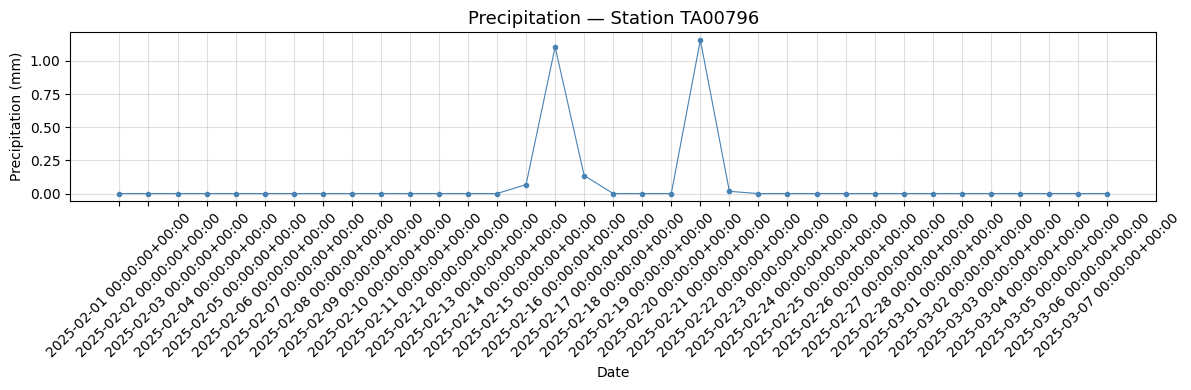

,TA00194,TA00195,TA00202,TA00240,TA00305,TA00381,TA00464,TA00468,TA00611,TA00612,TA00796,TA00797,TA00798,TA00799,TA00800,TA00816,TA00821,TA00882
2025-02-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.000,NaN,0.000,0.000,0.0
2025-02-02 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.000,NaN,0.000,0.000,0.0
2025-02-03 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.000,NaN,0.000,0.000,0.0
2025-02-04 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.000,NaN,0.000,0.000,0.0
2025-02-05 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.000,NaN,0.000,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-27 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,0.119,0.068,0.0
2025-07-28 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,0.119,0.051,0.0
2025-07-29 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.578,NaN,0.136,0.051,0.0
2025-07-30 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.765,NaN,0.119,0.051,0.0


In [18]:
# # @title ### 4a_2: Extracting TAHMO Precipitation data and preview
# # @markdown Using filter-stations to extract precipitation data <br>
# # @title ### 4a_1: Extract and visualise TAHMO data using filter stations

# # @markdown ❌ SKIP this step if you have your own data

# # save to the directory

# # print('Extracting Precipitation Data ...')
# region_precip = rd.multiple_measurements(stations_list=info['code'].tolist(),
#                                      startDate=start_date,
#                                      endDate=end_date,
#                                      variables=['pr'],
#                                          csv_file=f'{dir_path}/Ground_data')

# # check if the file exist to know if it was successful
# if not os.path.exists(f'{dir_path}/Ground_data.csv'):
#     print("❌ Precipitation data not extracted successfully.")
# else:
#     print("✅ Precipitation data extracted successfully.")

# # Visualise any random station data
# def plot_stations_data_randomly(eac_data):
#     import random
#     station_codes = eac_data.columns.to_list()
#     random_station = random.choice(station_codes)
#     station_data = eac_data[random_station]

#     plt.figure(figsize=(10, 5))
#     plt.plot(station_data.index, station_data.values, marker='o')
#     plt.title(f'Precipitation Data for Station {random_station}')
#     plt.xlabel('Date')

#     # Rotate date labels for better readability
#     plt.xticks(rotation=45)

#     plt.ylabel('Precipitation (mm)')
#     plt.grid(True)
#     plt.show()

#     print(f"Station Code: {random_station}")
#     print(f"Data Range: {station_data.min()} mm to {station_data.max()} mm")
#     print(f"Number of Records: {len(station_data)}")

# # plot_stations_data_randomly(region_precip)

# region_precip
# @title ### 4a_2: Extracting TAHMO Precipitation data and preview (robust version)
# @markdown Replaces original block — handles network drops, retries missing stations,
# @markdown and guarantees Ground_data.csv is saved to Drive before continuing.


# @title ### 4a_2: Extracting TAHMO Precipitation data and preview
import os, time, random
import pandas as pd
import matplotlib.pyplot as plt

# ── SMART CACHING: TAHMO PRECIPITATION ────────────────────────────────────────
def generate_precip(local_path):
    """Robustly extracts TAHMO precipitation data in batches.

    Handles the case where info (station metadata) is empty — e.g. a country
    with 0 TAHMO stations in the selected region — by writing an empty CSV
    immediately instead of attempting extraction with no stations to query.
    """
    stations_list = info['code'].tolist() if not info.empty else []

    if not stations_list:
        print("   ℹ️  No stations available for this country (0 stations found in Step 4a_1).")
        print("   📝 Writing empty precipitation file — nothing to extract.")
        pd.DataFrame().to_csv(local_path)
        return

    print("   🔄 Extracting TAHMO precipitation data (this may take a few minutes)...")
    MAX_RETRIES = 3
    RETRY_DELAY = 10
    BATCH_SIZE = 5

    batches = [stations_list[i:i+BATCH_SIZE] for i in range(0, len(stations_list), BATCH_SIZE)]
    all_data = []

    for b_idx, batch in enumerate(batches):
        for attempt in range(1, MAX_RETRIES + 1):
            try:
                result = rd.multiple_measurements(
                    stations_list=batch,
                    startDate=start_date,
                    endDate=end_date,
                    variables=['pr'],
                )
                if result is not None and not result.empty:
                    all_data.append(result)
                    break
            except Exception as e:
                if attempt < MAX_RETRIES:
                    time.sleep(RETRY_DELAY)

    if all_data:
        region_precip_df = pd.concat(all_data, axis=1)
        region_precip_df = region_precip_df.loc[:, ~region_precip_df.columns.duplicated()]
        region_precip_df.to_csv(local_path)
        print(f"   ✅ Extracted {region_precip_df.shape[1]} stations.")
    else:
        # Extraction was attempted but yielded nothing (API errors, no data
        # for the date range, etc.) — still write an empty file so the cache
        # upload step below has something to copy, and so Run All can continue.
        print("   ❌ Failed to extract any data — writing empty placeholder.")
        pd.DataFrame().to_csv(local_path)

precip_path = load_or_generate('Ground_data.csv', generate_precip)

# Reading back: an empty/placeholder CSV parses to a DataFrame with no
# columns, which read_csv(..., index_col=0) handles fine — region_precip
# will simply be empty, and the checks below already account for that.
region_precip = pd.read_csv(precip_path, index_col=0)

if region_precip.empty:
    print(f"\n⚠️  No precipitation data available for {COUNTRY}. "
          f"Downstream steps will show empty results for this country.")

# ── VISUALISATION (Runs every time, regardless of cache) ──────────────────────
def plot_stations_data_randomly(eac_data):
    if eac_data.empty: return
    non_empty = [c for c in eac_data.columns if eac_data[c].notna().sum() > 10]
    if not non_empty: return
    random_station = random.choice(non_empty)
    station_data = eac_data[random_station].dropna()
    plt.figure(figsize=(12, 4))
    plt.plot(station_data.index, station_data.values, marker='o', markersize=3, linewidth=0.8, color='steelblue')
    plt.title(f'Precipitation — Station {random_station}', fontsize=13)
    plt.xlabel('Date'); plt.ylabel('Precipitation (mm)')
    plt.xticks(rotation=45); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

if not region_precip.empty:
    plot_stations_data_randomly(region_precip)
    display(region_precip)
else:
    print("⚠️ region_precip is empty.")


In [19]:
# @title ### 4b_1) Upload custom data {"display-mode":"form"}
# @markdown ❌ SKIP this step if you are using TAHMO data

# @markdown Please upload your Ground_Metadata.csv and Ground_data.csv files.

import os
import pandas as pd

# Use a LOCAL variable for the custom data path so we never overwrite the
# global dir_path (which points to the TAHMO cache folder set in Step 1).
# This means switching between 'custom' and 'TAHMO' modes never breaks Step 6a.
_custom_dir_path = './data/ground'
os.makedirs(_custom_dir_path, exist_ok=True)

if not os.path.exists(_custom_dir_path):
    print("❌ Path not created successfully.")
else:
    print("✅ Path created successfully.")

# Only proceed with custom data upload if Ground_data_source is set to 'custom'
if Ground_data_source.lower() == 'custom':
    from google.colab import files

    # Paths for saving
    metadata_save_path = os.path.join(_custom_dir_path, 'Ground_Metadata.csv')
    data_save_path = os.path.join(_custom_dir_path, 'Ground_data.csv')

    # Upload Ground_Metadata.csv
    print("\nPlease upload Ground_Metadata.csv:")
    uploaded_metadata = files.upload()
    if not uploaded_metadata:
        print("❌ No file uploaded for Ground_Metadata.csv")
    else:
        uploaded_file_name = list(uploaded_metadata.keys())[0]
        os.rename(uploaded_file_name, metadata_save_path)
        print(f"✅ File saved as 'Ground_Metadata.csv' in {dir_path}")

    # Upload Ground_data.csv
    print("\nPlease upload Ground_data.csv:")
    uploaded_data = files.upload()
    if not uploaded_data:
        print("❌ No file uploaded for Ground_data.csv.")
    else:
        uploaded_file_name = list(uploaded_data.keys())[0]
        os.rename(uploaded_file_name, data_save_path)
        print(f"✅ File saved as 'Ground_data.csv' in {dir_path}")

    # --- Validation ---
    region_metadata = None
    region_precip_data = None

    # Validate Ground_Metadata.csv if uploaded
    if os.path.exists(metadata_save_path):
        try:
            region_metadata = pd.read_csv(metadata_save_path)
            required_metadata_cols = ['Code', 'lat', 'lon']
            if not all(col in region_metadata.columns for col in required_metadata_cols):
                print(f"❌ Error: Ground_Metadata.csv must contain the columns: {required_metadata_cols}")
                region_metadata = None
            else:
                print("✅ Ground_Metadata.csv columns validated.")
                # Rename columns to match expected format later in the notebook
                region_metadata = region_metadata.rename(columns={'Code': 'code'})

        except Exception as e:
            print(f"❌ Error reading Ground_Metadata.csv: {e}")
            region_metadata = None

    # Validate Ground_data.csv if uploaded
    if os.path.exists(data_save_path):
        try:
            region_precip_data = pd.read_csv(data_save_path)
            if 'Date' not in region_precip_data.columns:
                print("❌ Error: Ground_data.csv must contain a 'Date' column.")
                region_precip_data = None
            else:
                print("✅ Ground_data.csv 'Date' column validated.")

        except Exception as e:
            print(f"❌ Error reading Ground_data.csv: {e}")
            region_precip_data = None

    # Display number of stations if data is loaded
    if region_precip_data is not None:
        # Assuming all columns except 'Date' are stations
        station_columns = [col for col in region_precip_data.columns if col != 'Date']
        print(f"\nTotal number of stations in Ground_data.csv: {len(station_columns)}")
else:
    print(f"Skipping custom data upload as Ground_data_source is set to '{Ground_data_source}'.")

✅ Path created successfully.
Skipping custom data upload as Ground_data_source is set to 'TAHMO'.


In [20]:
# @title ### 4b_2) Visualise and preview custom data {"display-mode":"form"}
# @markdown ❌ SKIP this step if you are using TAHMO data
# @markdown This cell loads and visualizes the custom data uploaded in Step 4b_1.

import os
import pandas as pd
import plotly.express as px

# Check if we should skip based on configuration
if Ground_data_source.lower() != 'custom':
    print(f"⏭️ Skipping custom data visualization as Ground_data_source is set to '{Ground_data_source}'.")
else:
    # Use local directory path consistent with Step 4b_1
    # (do NOT overwrite global dir_path — that points to TAHMO cache folder)
    _custom_dir_path = './data/ground'
    metadata_path = os.path.join(_custom_dir_path, 'Ground_Metadata.csv')
    data_path = os.path.join(_custom_dir_path, 'Ground_data.csv')

    # Try to use data already loaded in memory from Step 4b_1 to avoid redundant I/O
    if 'region_metadata' in locals() and 'region_precip_data' in locals() and not region_metadata.empty:
        print("✅ Using custom data already loaded in memory from Step 4b_1.")
    else:
        print("📂 Loading custom data from local files...")
        if not os.path.exists(metadata_path) or not os.path.exists(data_path):
            raise FileNotFoundError(f"❌ Custom data files not found at {_custom_dir_path}. Please run Step 4b_1 and upload the files.")
        region_metadata = pd.read_csv(metadata_path)
        region_precip_data = pd.read_csv(data_path)
        print("✅ Custom data loaded successfully.")

    # Display preview
    print("\n📊 Preview of first 5 rows of Ground_data.csv:")
    display(region_precip_data.head())

    # Robust visualization function (handles various column naming conventions)
    def plot_custom_stations(df_meta):
        # Normalize column names to lowercase for easy matching
        df_meta = df_meta.rename(columns=str.lower)

        # Map common variations to standard names
        col_map = {}
        for col in df_meta.columns:
            if col in ['lat', 'latitude']: col_map[col] = 'lat'
            elif col in ['lon', 'longitude', 'lng']: col_map[col] = 'lon'
            elif col in ['code', 'station_id', 'id', 'stationid']: col_map[col] = 'station_id'

        df_meta = df_meta.rename(columns=col_map)

        required = ['lat', 'lon']
        if not all(c in df_meta.columns for c in required):
            print(f"❌ Metadata missing required columns: {required}. Available: {list(df_meta.columns)}")
            return

        # Check for missing coordinates
        if df_meta[['lat', 'lon']].isnull().any().any():
            print("️ Warning: Some stations have missing coordinates. They will be excluded from the map.")
            df_meta = df_meta.dropna(subset=['lat', 'lon'])

        if df_meta.empty:
            print("❌ No valid stations with coordinates to plot.")
            return

        # Identify ID column for hover tooltip
        id_col = 'station_id' if 'station_id' in df_meta.columns else df_meta.columns[0]

        fig = px.scatter_mapbox(
            df_meta,
            lat="lat",
            lon="lon",
            hover_name=id_col,
            zoom=5,
            height=500,
            width=900,
            title="Custom Station Locations"
        )
        fig.update_layout(mapbox_style="open-street-map")
        fig.show()

    print("\n️ Visualizing custom station locations:")
    plot_custom_stations(region_metadata)

⏭️ Skipping custom data visualization as Ground_data_source is set to 'TAHMO'.


# **Step 5: Extract CHIRPS data**

In [21]:
# @title ### Extract the data from Google Earth engine project

# @markdown **Note**: Earth Engine is already authenticated in Step 1b.
# @markdown This step checks the Shared Drive cache first, and only pulls from GEE if necessary.

import os, glob
import xarray as xr
import pandas as pd
import ee

# ── Your GEE project ─────────────────────────────────────────────────────────
GEE_PROJECT = "natural-notch-435413-j3"

# ── Bounding boxes for countries you pull yourself [lon_min, lat_min, lon_max, lat_max]
COUNTRY_BBOX = {
    "Ethiopia":  [33.0,  3.0,  48.0, 15.0],
    "Tanzania":  [29.0, -12.0, 41.0, -1.0],
    "Eritrea":   [36.5, 12.5,  43.5, 18.0],
    "Djibouti":  [41.5,  10.9,  43.5, 12.7],
}

# ── SMART CACHING: CHIRPS DATA ────────────────────────────────────────────────
chirps_filename = f'CHIRPS_{start_date}_{end_date}_{COUNTRY}.nc'

def generate_chirps(local_path):
    """Pulls CHIRPS data from GEE and saves as NetCDF."""
    print("   🔄 Pulling CHIRPS data from GEE...")

    # EE is already initialized in Step 1b. We just verify it's responsive.
    try:
        ee.Number(1).getInfo()
    except Exception as e:
        raise RuntimeError(f"Earth Engine is not initialized or not responding. Please re-run Step 1b. Error: {e}")

    # Resolve bounding box
    if COUNTRY in COUNTRY_BBOX:
        roi = ee.Geometry.Rectangle(COUNTRY_BBOX[COUNTRY])
        print(f"   Bbox: {COUNTRY_BBOX[COUNTRY]}")
    elif 'region_geom' in globals() and globals()['region_geom']:
        roi = ee.Geometry.Polygon(globals()['region_geom'])
        print(f"   Using region_geom from Step 3")
    else:
        raise ValueError(
            f"No bounding box for '{COUNTRY}'. "
            f"Add it to COUNTRY_BBOX above, or set region_geom in Step 3."
        )

    # Pull CHIRPS pentad collection
    chirps_col = (
        ee.ImageCollection("UCSB-CHG/CHIRPS/PENTAD")
        .filterDate(start_date, end_date)
        .filterBounds(roi)
        .select("precipitation")
        .map(lambda img: img.clip(roi))
    )
    n = chirps_col.size().getInfo()
    print(f"   {n} pentad images found ({start_date} → {end_date})")

    # Install geemap if needed
    try:
        import geemap
    except ImportError:
        import subprocess
        subprocess.run(["pip", "install", "geemap", "-q"], check=True)
        import geemap

    from tqdm.notebook import tqdm

    # Download each pentad as a GeoTIFF (skips files already on disk)
    export_dir = f'./chirps_temp_{COUNTRY}'
    os.makedirs(export_dir, exist_ok=True)
    image_list = chirps_col.toList(n)

    for i in tqdm(range(n), desc=f"Exporting CHIRPS ({COUNTRY})", unit="file"):
        img      = ee.Image(image_list.get(i))
        date_str = img.date().format("yyyyMMdd").getInfo()
        out_file = os.path.join(export_dir, f"{date_str}.tif")
        if os.path.exists(out_file):
            continue
        geemap.ee_export_image(img, filename=out_file, scale=5500,
                               region=roi, file_per_band=False)

    # Assemble TIFFs → xarray
    tiff_files = sorted(glob.glob(os.path.join(export_dir, "*.tif")))
    print(f"   Converting {len(tiff_files)} TIFFs → NetCDF...")

    ds    = xr.open_mfdataset(tiff_files, combine="nested",
                              concat_dim="time", engine="rasterio")
    dates = [os.path.basename(f).split(".")[0] for f in tiff_files]
    ds    = ds.assign_coords(time=pd.to_datetime(dates, format="%Y%m%d"))
    ds    = ds.squeeze("band", drop=True).rename({"band_data": "precipitation"})
    ds.rio.write_crs("EPSG:4326", inplace=True)
    chirps_ds_temp = ds.where(ds != -9999)

    # Save to local directory
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    chirps_ds_temp.to_netcdf(local_path)
    print(f"   ✅ Saved to local cache: {local_path}")

# Execute smart caching (Checks Shared Drive -> Downloads if exists -> Generates & Uploads if missing)
chirps_path = load_or_generate(chirps_filename, generate_chirps)
chirps_ds = xr.open_dataset(chirps_path)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n✅ CHIRPS ready for '{COUNTRY}'")
print(f"   Dimensions : {dict(chirps_ds.dims)}")
print(f"   Variables  : {list(chirps_ds.data_vars)}")
print(f"   Time range : {chirps_ds.time.values[0]} → {chirps_ds.time.values[-1]}")


🔍 Cache check: CHIRPS_2025-02-01_2025-07-31_Ethiopia.nc
   ✅ Cache HIT — copying from Shared Drive...
   💾 Ready at: ./Datasets/Ethiopia/CHIRPS_2025-02-01_2025-07-31_Ethiopia.nc

✅ CHIRPS ready for 'Ethiopia'
   Dimensions : {'time': 36, 'y': 247, 'x': 304}
   Variables  : ['precipitation']
   Time range : 2025-02-01T00:00:00.000000000 → 2025-07-26T00:00:00.000000000


# **Step 6: Visualise data availability for ground stations and handle missing data**


In [22]:
# @title ### 6a) Load the extracted Ground Precipitation and Metadata

import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# ── Resolve the correct dir_path for ground data ─────────────────────────────
# Cells 4b_1 and 4b_2 (custom data upload) previously overwrote the global
# dir_path to './data/ground'. For TAHMO mode, the files were saved to
# COUNTRY_LOCAL_DIR (e.g. './Datasets/Ethiopia/') by Steps 4a_1 and 4a_2.
# Always re-derive dir_path here so Step 6a finds the files regardless of
# which cells ran before it and in what order.
if Ground_data_source.lower() == 'tahmo':
    dir_path = COUNTRY_LOCAL_DIR   # where load_or_generate() wrote the files
else:
    dir_path = './data/ground'     # where 4b_1 custom-upload saves files

# Check if files exist
ground_data_path = os.path.join(dir_path, 'Ground_data.csv')
ground_metadata_path = os.path.join(dir_path, 'Ground_Metadata.csv')

if not os.path.exists(ground_data_path) or not os.path.exists(ground_metadata_path):
    raise FileNotFoundError(
        f"❌ Ground data files not found in {dir_path}.\n"
        f"   For TAHMO mode: ensure Steps 4a_1 and 4a_2 ran successfully.\n"
        f"   For custom mode: ensure Step 4b_1 ran and files were uploaded."
    )

print("📂 Loading ground data from local directory...")
region_precip_data = pd.read_csv(ground_data_path)
region_metadata = pd.read_csv(ground_metadata_path)

# ── Handle the "0 stations / no data" case (e.g. Eritrea, Djibouti) ───────────
# Steps 4a_1/4a_2 write an empty CSV when no TAHMO stations are found in the
# region. An empty CSV has no 'Date' column, so the formatting below would
# crash with a KeyError. Detect this up front and skip formatting cleanly.
if region_precip_data.empty or region_metadata.empty:
    print(f"⚠️  No ground data available for {COUNTRY} "
          f"(0 stations found in the selected region).")
    print("   Skipping formatting — downstream cells will show empty results "
          "for this country.")
    region_precip_data = pd.DataFrame()
    region_metadata = pd.DataFrame(columns=['code', 'lat', 'lon'])
else:
    # Handle column renaming based on data source
    if Ground_data_source.lower() == 'tahmo':
        region_metadata = region_metadata[['code', 'location.latitude', 'location.longitude']].rename(
            columns={'location.latitude': 'lat', 'location.longitude': 'lon'}
        )
    elif Ground_data_source.lower() == 'custom':
        region_metadata = region_metadata.rename(columns={'Code': 'code'})
        region_metadata = region_metadata[['code', 'lat', 'lon']]
        # Rename the date column for consistency if it's named 'Date'
        if 'Date' in region_precip_data.columns:
            region_precip_data = region_precip_data.rename(columns={"Date": "Unnamed: 0"})

    # Format the precipitation data index
    if 'Unnamed: 0' in region_precip_data.columns:
        region_precip_data = region_precip_data.rename(columns={"Unnamed: 0": "Date"})

    if 'Date' not in region_precip_data.columns:
        print(f"⚠️  No 'Date' column found for {COUNTRY} — treating as no data available.")
        region_precip_data = pd.DataFrame()
    else:
        region_precip_data['Date'] = pd.to_datetime(region_precip_data['Date'], format='mixed', dayfirst=True)
        region_precip_data = region_precip_data.set_index('Date')
        region_precip_data.index = region_precip_data.index.tz_localize(None)

        # Drop multiple sensor columns if they exist (e.g., columns with '_' in their names)
        multiple_sensors = [i for i in region_precip_data.columns if len(str(i).split('_')) > 1]
        if multiple_sensors:
            region_precip_data = region_precip_data.drop(columns=multiple_sensors)

print("✅ Step 6a successful. Ground data loaded and formatted.")

FileNotFoundError: ❌ Ground data files not found in ./data/ground. Please ensure Steps 4a_1 and 4a_2 have been run successfully.

In [ ]:
# @title ### 6b) Check the range of the data and plot any of the stations randomly
# @markdown Rerun this cell to visualise the next random station in the region <br>
import random
import matplotlib.pyplot as plt

def plot_stations_data_randomly(eac_data):
    # Drop columns that are completely empty to avoid choosing an empty station
    valid_stations = [col for col in eac_data.columns if eac_data[col].notna().any()]
    if not valid_stations:
        print("No stations with valid data available to plot.")
        return

    random_station = random.choice(valid_stations)
    station_data = eac_data[random_station].dropna()

    plt.figure(figsize=(10, 5))
    plt.plot(station_data.index, station_data.values, marker='o', linestyle='-', markersize=4)
    plt.title(f'Precipitation Data for Station {random_station}')
    plt.xlabel('Date')

    # Rotate date labels for better readability
    plt.xticks(rotation=45)

    plt.ylabel('Precipitation (mm)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"Station Code: {random_station}")
    print(f"Data Range: {station_data.min():.2f} mm to {station_data.max():.2f} mm")
    print(f"Number of Records: {len(station_data)}")

if 'region_precip_data' in locals() and not region_precip_data.empty:
    plot_stations_data_randomly(region_precip_data)
else:
    print("No precipitation data available to plot.")

In [ ]:
# @title ### 6c) Visualise missing data for each station {"display-mode":"form"}
# @markdown The generated chart shows the available data on y axis and a heatmap of missing data.
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors
import matplotlib.patches as mpatches

if 'region_precip_data' in locals() and not region_precip_data.empty:
    # Drop stations with multiple sensors station_sensor columns (if any exist)
    multiple_sensors = [i for i in region_precip_data.columns if isinstance(i, str) and len(i.split('_')) > 1]
    region_precip_data_filtered = region_precip_data.drop(columns=multiple_sensors)

    if region_precip_data_filtered.empty:
        print("No data available to generate the missing data heatmap.")
    else:
        # Calculate missing data matrix per station over time
        missing_data = region_precip_data_filtered.isnull().T

        # Safely format index to strings (handles both tz-aware and tz-naive datetimes)
        # Slicing [:10] extracts just the 'YYYY-MM-DD' part for cleaner x-axis labels
        missing_data.columns = [str(col)[:10] for col in missing_data.columns]

        # Calculate overall completeness percentage for each station
        overall_completeness = (1 - region_precip_data_filtered.isnull().mean(axis=0)) * 100

        # Sort stations by overall completeness in descending order
        sorted_stations = overall_completeness.sort_values(ascending=False).index
        missing_data_sorted = missing_data.loc[sorted_stations]

        # Determine the number of stations to dynamically adjust height
        num_stations = len(missing_data_sorted)
        base_height = 5  # Base height in inches
        height_per_station = 0.15 # Adjusted slightly for better readability
        fig_height = max(5, base_height + num_stations * height_per_station)

        # Create a custom colormap: Blue for non-missing (False), Red for missing (True)
        cmap = matplotlib.colors.ListedColormap(['blue', 'red'])

        plt.figure(figsize=(12, fig_height))
        sns.heatmap(missing_data_sorted, cbar=False, cmap=cmap, vmin=0, vmax=1)

        # Create legend patches
        blue_patch = mpatches.Patch(color='blue', label='Available Data')
        red_patch = mpatches.Patch(color='red', label='Missing Data')

        # Add legend to the plot
        plt.legend(handles=[blue_patch, red_patch], title="Data Status", loc='upper right')

        # Update y-axis labels to include completeness percentage
        ax = plt.gca()
        y_labels = [f"{label.get_text()} ({overall_completeness.loc[label.get_text()]:.1f}%)" for label in ax.get_yticklabels()]
        ax.set_yticklabels(y_labels)

        plt.title('Missing Data Heatmap by Station and Date')
        plt.xlabel('Date')
        plt.ylabel('Station (Completeness)')
        plt.xticks(rotation=90) # Rotate x-axis labels
        plt.tight_layout()
        plt.show()
else:
    print("No precipitation data available to generate the missing data heatmap.")

# **Step 7: Aggregate the Ground data to Pentads**

In [ ]:

# @title Aggregate station rain to pentads to match CHIRPS {"display-mode":"form"}
# @markdown In order to match CHIRPS and how it is extracted we will aggregate the data to pentads (5 days)

import pandas as pd
import random
import matplotlib.pyplot as plt

if 'region_precip_data' not in locals() or region_precip_data.empty:
    print("⚠️ Ground precipitation data not loaded. Please run the previous steps to load ground data.")
    region_precip_pentad = pd.DataFrame()
else:
    # Aggregate to 5-day pentads using sum
    region_precip_pentad = region_precip_data.resample('5D').sum()

    # Drop the last row if it's an incomplete pentad (less than 5 days)
    if len(region_precip_pentad) > 0:
        last_day = region_precip_pentad.index[-1].day
        # CHIRPS pentads typically start on 1, 6, 11, 16, 21, 26.
        # If the last day doesn't align with a standard pentad start, drop it.
        if last_day not in [1, 6, 11, 16, 21, 26, 31]:
            region_precip_pentad = region_precip_pentad[:-1]

    print("✅ Ground data aggregated to pentads.")

    def plot_stations_data_randomly(eac_data):
        valid_stations = [col for col in eac_data.columns if eac_data[col].notna().any()]
        if not valid_stations:
            print("No valid stations to plot.")
            return

        random_station = random.choice(valid_stations)
        station_data = eac_data[random_station].dropna()

        plt.figure(figsize=(10, 5))
        plt.plot(station_data.index, station_data.values, marker='o')
        plt.title(f'Pentad Precipitation Data for Station {random_station}')
        plt.xlabel('Date')
        plt.xticks(rotation=45)
        plt.ylabel('Precipitation (mm)')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        print(f"Station Code: {random_station}")
        print(f"Data Range: {station_data.min():.2f} mm to {station_data.max():.2f} mm")
        print(f"Number of Records: {len(station_data)}")

    plot_stations_data_randomly(region_precip_pentad)

# **Step 8: Build CHIRPS Nearest data for the ground stations**

In [ ]:
# @title Build station dataset from satellite grids (CHIRPS) {"display-mode":"form"}
# @markdown This step builds the station dataset by using the station metadata (latitude and longitude)
# @markdown to extract the nearest grid values from the satellite products (e.g., CHIRPS).

import numpy as np
import pandas as pd
import xarray as xr

def build_station_dataset_from_grid(grid_ds, stations_metadata, k=NEIGHBORHOOD):
    """
    Build station dataset by sampling grid values at station locations.
    """
    if grid_ds is None:
        return pd.DataFrame()

    all_stations_data = {}

    # Check for 'lat'/'lon' or 'y'/'x' dimensions
    if 'lat' in grid_ds.coords and 'lon' in grid_ds.coords:
        grid_lats = grid_ds['lat'].values
        grid_lons = grid_ds['lon'].values
        lat_dim, lon_dim = 'lat', 'lon'
    elif 'y' in grid_ds.coords and 'x' in grid_ds.coords:
        grid_lats = grid_ds['y'].values
        grid_lons = grid_ds['x'].values
        lat_dim, lon_dim = 'y', 'x'
    else:
        print("⚠️ Could not find 'lat'/'lon' or 'y'/'x' dimensions in dataset.")
        return pd.DataFrame()

    # Find the precipitation variable name
    precip_var = None
    for var in grid_ds.data_vars:
        if any(k in var.lower() for k in ['precip', 'rainfall', 'rfe']):
             if (lat_dim in grid_ds[var].dims and lon_dim in grid_ds[var].dims and 'time' in grid_ds[var].dims):
                 precip_var = var
                 break

    if precip_var is None:
        print("⚠️ Could not find a precipitation variable in the dataset.")
        return pd.DataFrame()

    for _, row in stations_metadata.iterrows():
        station_code = row['code']
        lat = row['lat']
        lon = row['lon']

        lat_idx = np.abs(grid_lats - lat).argmin()
        lon_idx = np.abs(grid_lons - lon).argmin()

        if k == 1:
            station_da = grid_ds[precip_var].isel({lat_dim: lat_idx, lon_dim: lon_idx})
        else:
            lat_slice = slice(max(lat_idx - k // 2, 0), min(lat_idx + k // 2 + 1, len(grid_lats)))
            lon_slice = slice(max(lon_idx - k // 2, 0), min(lon_idx + k // 2 + 1, len(grid_lons)))
            sub = grid_ds[precip_var].isel({lat_dim: lat_slice, lon_dim: lon_slice})

            if sub[lat_dim].size == 0 or sub[lon_dim].size == 0:
                 all_stations_data[station_code] = pd.Series(dtype=float)
                 continue

            station_da = sub.mean(dim=[lat_dim, lon_dim], skipna=True)

        try:
            station_series = station_da.to_series()
            station_series.name = station_code
            all_stations_data[station_code] = station_series
        except Exception as e:
             print(f"Error converting xarray to series for station {station_code}: {e}")
             all_stations_data[station_code] = pd.Series(dtype=float)

    if not all_stations_data:
        return pd.DataFrame()

    combined_df = pd.concat(all_stations_data.values(), axis=1, keys=all_stations_data.keys())
    return combined_df

# Ensure metadata is available
if 'region_metadata' not in locals() or region_metadata.empty:
    print("⚠️ Ground metadata not loaded. Please run previous steps to load ground data.")
    chirps_station_df = pd.DataFrame()
else:
    if 'chirps_ds' not in locals() or chirps_ds is None:
        print("⚠️ CHIRPS dataset not loaded. Please run previous steps to load satellite data.")
        chirps_station_df = pd.DataFrame()
    else:
        print("Extracting pentad data for all stations from CHIRPS...")
        chirps_ds_filtered = chirps_ds.sel(time=slice(start_date, end_date))

        chirps_station_df = build_station_dataset_from_grid(chirps_ds_filtered, region_metadata, k=NEIGHBORHOOD)

        if not chirps_station_df.empty:
            print("✅ Station data extracted for CHIRPS.")
            display(chirps_station_df.head())
        else:
            print("⚠️ No station data extracted for CHIRPS.")

# **Step 9: Visualise CHIRPS vs the Ground stations**

In [ ]:
# @title ### 9) Plot the CHIRPS data and Ground equivalents for a random station
# @markdown Every single time we run this cell we get to visualise the CHIRPS v Ground data comparison for a different station within the region

import random
import matplotlib.pyplot as plt

# Ensure the datasets exist
if 'region_precip_pentad' not in locals() or 'chirps_station_df' not in locals():
    print("⚠️ Required pentad datasets not found. Please ensure Steps 5 and 6 have been run successfully.")
else:
    chirps_stations = chirps_station_df

    def plot_chirps_vs_ground_randomly(eac_pentad, chirps_stations, station_code=None):
        if station_code is None:
            station_codes = eac_pentad.columns.intersection(chirps_stations.columns).tolist()
            if not station_codes:
                print("No common stations between Ground pentad data and CHIRPS data.")
                return

            random_station = random.choice(station_codes)
        else:
            random_station = station_code

        # Check if the station has valid data
        if random_station not in eac_pentad.columns or random_station not in chirps_stations.columns:
            print(f"Station {random_station} not found in both datasets.")
            return

        ground_data = eac_pentad[random_station].dropna()
        chirps_data = chirps_stations[random_station].dropna()

        if ground_data.empty or chirps_data.empty:
            print(f"No valid overlapping data for station {random_station}.")
            return

        plt.figure(figsize=(10, 5))
        plt.plot(ground_data.index, ground_data.values, marker='o', label='Ground (TAHMO)', color='blue')
        plt.plot(chirps_data.index, chirps_data.values, marker='x', label='CHIRPS', color='orange')
        plt.title(f'Precipitation Comparison for Station {random_station}')
        plt.xlabel('Date')

        # Rotate date labels for better readability
        plt.xticks(rotation=45)

        plt.ylabel('Precipitation (mm)')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        print(f"Station Code: {random_station}")
        print(f"Ground Data Range: {ground_data.min():.2f} mm to {ground_data.max():.2f} mm")
        print(f"CHIRPS Data Range: {chirps_data.min():.2f} mm to {chirps_data.max():.2f} mm")
        print(f"Number of Ground Records: {len(ground_data)}")
        print(f"Number of CHIRPS Records: {len(chirps_data)}")

    plot_chirps_vs_ground_randomly(region_precip_pentad, chirps_stations)

# **Step 10: Compute station confidence scores**

In [ ]:
# @title ### 10a) Run this cell to compute station scores
# @title Confidence Score Formula
# @markdown ### **Confidence Score Formula**
# @markdown For each station, the confidence score is computed as:
# @markdown
# @markdown $$
# @markdown \text{Confidence Score} = 100 \times \big(0.1 \cdot C \;+\; 0.5 \cdot r \;+\; 0.1 \cdot (1 - O) \;+\; 0.3 \cdot(1- b) \big)
# @markdown $$
# @markdown
# @markdown Where:
# @markdown - $C = 1 -$ (missing fraction of observations), i.e. **completeness**
# @markdown - $r =$ Spearman/Pearson correlation coefficient between observed and CHIRPS pentads
# @markdown - $O =$ fraction of outliers (observed values < 0)
# @markdown - $b =$ Bias Significance - paired $t$-test between observed and simulated values (significant if $p < 0.05$)
# @markdown
# @markdown ---
# @markdown
# @markdown **Additional metrics per station:**
# @markdown
# @markdown - **RMSE**
# @markdown $$
# @markdown \text{RMSE} = \sqrt{\frac{1}{n} \sum (obs - sim)^2}
# @markdown $$
# @markdown
# @markdown - **Adjusted confidence score**
# @markdown $$
# @markdown \text{Adjusted Confidence Score} = \text{Confidence Score} - \text{RMSE}
# @markdown $$

import os
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, ttest_rel, spearmanr

# Ensure the datasets exist
if 'region_precip_pentad' not in locals() or 'chirps_station_df' not in locals():
    print("⚠️ Required pentad datasets not found. Please ensure Steps 5 and 6 have been run successfully.")
else:
    # @title RMSE
    def rmse(a, b):
        a = np.asarray(a, dtype=float)
        b = np.asarray(b, dtype=float)
        return float(np.sqrt(np.nanmean((a - b) ** 2)))

    def compute_station_scores(eac_pentad, chirps_stations):
        # get the union stations
        stations = eac_pentad.columns.intersection(chirps_stations.columns)
        if stations.empty:
            print("No common stations between Ground pentad data and CHIRPS data.")
            return None

        # choose only the matching dates by checking the index
        union_dates = eac_pentad.index.intersection(chirps_stations.index)
        eac_pentad = eac_pentad.loc[union_dates]
        chirps_stations = chirps_stations.loc[union_dates]

        scores = []
        for station in stations:
            obs = eac_pentad[station]
            sim = chirps_stations[station]

            # Drop NaNs for correlation and RMSE calculation
            valid_mask = obs.notna() & sim.notna()
            obs_valid = obs[valid_mask]
            sim_valid = sim[valid_mask]

            if len(obs_valid) < 3:
                continue # Need at least 3 points for meaningful stats

            if CORR_METHOD.lower() == 'pearson':
                corr, _ = pearsonr(obs_valid, sim_valid)
            else:
                corr, _ = spearmanr(obs_valid, sim_valid)

            # Compute metrics
            error = rmse(obs_valid, sim_valid)

            # T-test requires at least 2 observations
            if len(obs_valid) >= 2:
                t_stat, p_val = ttest_rel(obs_valid, sim_valid)
                bias_signif = 'Significant' if p_val < 0.05 else 'Not Significant'
            else:
                p_val = np.nan
                bias_signif = 'Insufficient data'

            completeness = 1 - obs.isna().mean()
            outlier_rate = (obs < 0).mean()

            confidence_score = 100 * (
                w_complete * completeness +
                w_corr * np.nan_to_num(corr, nan=0) +
                w_outlier * (1 - outlier_rate) +
                w_bias * (1 - np.nan_to_num(p_val, nan=1.0))
            )

            scores.append(
                {
                    'station_id': station,
                    'confidence_score': confidence_score,
                    f'{CORR_METHOD}_r': corr,
                    'rmse': error,
                    'bias_signif': bias_signif,
                    'completeness': completeness,
                    'outlier_rate': outlier_rate,
                    'p_value': p_val
                }
            )
        scores_df = pd.DataFrame(scores)
        return scores_df

    station_scores = compute_station_scores(region_precip_pentad, chirps_station_df)

    if station_scores is not None and not station_scores.empty:
        # to the confidence scores subtract the rmse
        station_scores['adjusted_confidence_score'] = station_scores['confidence_score'] - station_scores['rmse']

        # Display top 20
        display(station_scores.sort_values(by='adjusted_confidence_score', ascending=False).head(20))

        # save the stations with the confidence scores
        # FIX: Corrected typo 'cores_output_path' to 'scores_output_path'
        scores_output_path = os.path.join(BASE_OUT, f'station_scores_{COUNTRY}.csv')
        station_scores.to_csv(scores_output_path, index=False)
        print(f"💾 Station scores saved to {scores_output_path}")
    else:
        print("⚠️ No scores computed. Check if there are common stations with valid data.")

In [ ]:
# @title 10b) Export the confidence scores results to excel file
import os

# Ensure output directory exists
os.makedirs(BASE_OUT, exist_ok=True)

output_path = os.path.join(BASE_OUT, f'station_scores_{region_query}.xlsx')
print(f'Exporting station scores to Excel: {output_path} ...')

if 'station_scores' in locals() and station_scores is not None and not station_scores.empty:
    station_scores.to_excel(output_path, index=False)
    print(f'✅ Successfully saved station scores to {output_path}')
else:
    print("⚠️ No station scores data available to export.")

In [ ]:
# @title 10c) Visualise station confidence
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

def plot_station_vs_chirps_and_confidence_interactive(
    station_pentad_df,
    chirps_pentad_df,
    station_scores_df,
    metadata_df,
    country_label="Country",
    high_thr=70,
    low_thr=40,
    min_pairs=3,
    scatter_color="#3366cc",
    width=900,
    height=600,
    corr_method_label='spearman_r'
):
    """
    Scatter: single color (no category legend)
    Geo map: always shows High / Medium / Low categories
    Returns:
      m_long, score_map, scatter_fig, map_fig
    """
    # -------- 1. Build long paired dataset --------
    common = station_pentad_df.columns.intersection(chirps_pentad_df.columns)
    rows = []
    for sid in common:
        s_obs = station_pentad_df[sid]
        s_sat = chirps_pentad_df[sid]
        pair = pd.DataFrame({'station_pentad': s_obs, 'sat_pentad': s_sat}).dropna()
        if len(pair) >= min_pairs:
            pair['station_id'] = sid
            pair['time'] = pair.index
            rows.append(pair)

    if not rows:
        print("No stations with sufficient paired data.")
        return None, None, None, None

    m_long = pd.concat(rows, axis=0).reset_index(drop=True)

    # -------- 2. Always compute classification for map --------
    sc = station_scores_df.copy()
    if 'class' not in sc.columns:
        def classify_fn(v):
            if v >= high_thr: return 'High'
            if v >= low_thr: return 'Medium'
            return 'Low'
        sc['class'] = sc['confidence_score'].apply(classify_fn)

    # enforce category ordering even if some missing
    cls_order = ['High','Medium','Low']
    sc['class'] = pd.Categorical(sc['class'], categories=cls_order, ordered=True)

    # -------- 3. Merge with metadata --------
    # Handle different metadata column names ('code' vs 'station_id')
    if 'code' in metadata_df.columns and 'station_id' not in metadata_df.columns:
        meta = metadata_df.rename(columns={'code':'station_id'})
    else:
        meta = metadata_df

    score_map = sc.merge(meta, on='station_id', how='left').dropna(subset=['lat','lon'])
    score_map['class'] = pd.Categorical(score_map['class'], categories=cls_order, ordered=True)

    # -------- 4. Merge scores into long paired --------
    merge_cols = ['station_id','confidence_score','class', corr_method_label, 'rmse','completeness','outlier_rate','bias_signif']
    existing = [c for c in merge_cols if c in sc.columns]
    m_long = m_long.merge(sc[existing], on='station_id', how='left')

    # -------- 5. Scatter (single color) --------
    lim_max = float(max(m_long['station_pentad'].max(), m_long['sat_pentad'].max()))
    hover_data = {
        'station_id': True,
        'time': True,
        'station_pentad': ':.2f',
        'sat_pentad': ':.2f',
        'confidence_score': ':.1f',
        'class': True,
        corr_method_label: ':.3f',
        'rmse': ':.2f',
        'completeness': ':.2f',
        'outlier_rate': ':.3f',
        'bias_signif': True
    }
    scatter_fig = px.scatter(
        m_long,
        x='station_pentad',
        y='sat_pentad',
        title=f"{country_label}: Station vs CHIRPS (Pentad)",
        hover_data=hover_data,
        labels={'station_pentad':'Station (mm)','sat_pentad':'CHIRPS (mm)'},
        width=width,
        height=height
    )
    scatter_fig.update_traces(marker=dict(color=scatter_color))
    scatter_fig.update_layout(showlegend=False)
    scatter_fig.add_trace(
        go.Scatter(
            x=[0, lim_max],
            y=[0, lim_max],
            mode='lines',
            line=dict(dash='dash', color='black'),
            name='1:1'
        )
    )
    scatter_fig.update_xaxes(constrain='domain')
    scatter_fig.update_yaxes(scaleanchor=None)

    # -------- 6. Geo Map (with categories, OSM basemap) --------
    palette = {'High':'green','Medium':'orange','Low':'red'}
    map_fig = px.scatter_mapbox(
        score_map,
        lat='lat',
        lon='lon',
        color='class',
        color_discrete_map=palette,
        hover_name='station_id',
        hover_data={
            'confidence_score': ':.1f',
            corr_method_label: ':.3f',
            'rmse': ':.2f',
            'completeness': ':.2f',
            'outlier_rate': ':.3f',
            'bias_signif': True,
            'lat': ':.3f',
            'lon': ':.3f'
        },
        title=f"{country_label} Station Confidence",
        zoom=5,
        height=height,
        width=width
    )
    map_fig.update_layout(
        mapbox_style="open-street-map",
        legend_title_text=f"Confidence<br>(High ≥ {high_thr}, Low < {low_thr})"
    )

    if {'lat','lon'}.issubset(score_map.columns) and len(score_map):
        lat_min, lat_max = score_map['lat'].min(), score_map['lat'].max()
        lon_min, lon_max = score_map['lon'].min(), score_map['lon'].max()
        lat_center = (lat_min + lat_max) / 2
        lon_center = (lon_min + lon_max) / 2
        map_fig.update_layout(
            mapbox_center={"lat": lat_center, "lon": lon_center},
            mapbox_zoom=5
        )

    return m_long, score_map, scatter_fig, map_fig

# Get thresholds from Step 1 configuration
high_thr = int(High_confidence_threshold)
low_thr = int(Low_confidence_threshold)

print(f"High threshold: {high_thr}")
print(f"Low threshold: {low_thr}")

# Check if required variables exist before plotting
if 'region_precip_pentad' in locals() and 'chirps_station_df' in locals() and 'station_scores' in locals():
    m_pairs, score_with_meta, scatter_fig, map_fig = plot_station_vs_chirps_and_confidence_interactive(
        region_precip_pentad,
        chirps_station_df, # Updated variable name from previous steps
        station_scores,
        region_metadata,
        country_label=f"{region_query}",
        high_thr=high_thr,
        low_thr=low_thr,
        scatter_color="#3366cc",
        width=900,
        height=600,
        corr_method_label=f'{CORR_METHOD}_r' # Pass dynamic correlation method name
    )

    if scatter_fig is not None:
        scatter_fig.show()
    if map_fig is not None:
        map_fig.show()
else:
    print("⚠️ Required data (region_precip_pentad, chirps_station_df, station_scores) not found. Please run previous steps.")